# Importación de librerias necesarias

In [46]:
# Realizamos la importacion de librerias necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
from sklearn.model_selection import train_test_split
import soundfile as sf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from mlxtend.evaluate import confusion_matrix
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, SimpleRNN, GRU, BatchNormalization, Input, Masking, Bidirectional, LSTM, Dense, Dropout
from keras import callbacks as call
from keras.models import Model
import matplotlib.pyplot as plt
import os
from keras.utils import plot_model
from keras.optimizers import Adam

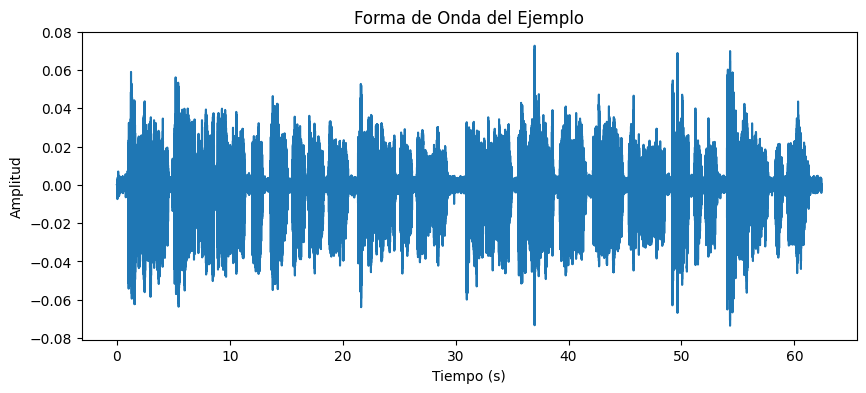

In [47]:
def graficar_forma_onda(audio, sr, titulo="Forma de Onda"):
    plt.figure(figsize=(10, 4))
    plt.plot(np.linspace(0, len(audio) / sr, len(audio)), audio)
    plt.title(titulo)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.show()

# Ejemplo: cargar un audio y graficarlo
audio_ejemplo, sr = librosa.load('ReconocimientoDeVoz/archive/16000_pcm_speeches/Edwin_audios/Edwin_voice_recording.wav', sr=16000)
graficar_forma_onda(audio_ejemplo, sr, titulo="Forma de Onda del Ejemplo")

Grafica la forma de onda de un audio de ejemplo.

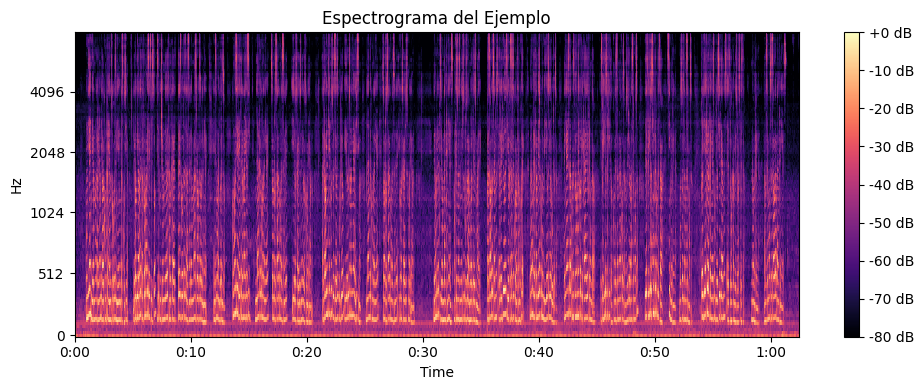

In [48]:
def graficar_espectrograma(audio, sr, titulo="Espectrograma"):
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', fmax=8000)
    plt.colorbar(format='%+2.0f dB')
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

graficar_espectrograma(audio_ejemplo, sr, titulo="Espectrograma del Ejemplo")

Grafica el espectrograma mel del audio de ejemplo.

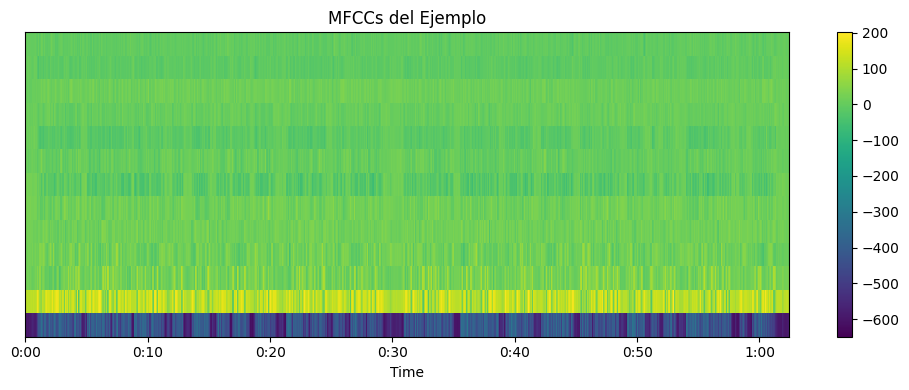

In [49]:
def graficar_mfccs(audio, sr, titulo="MFCCs"):
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap='viridis')
    plt.colorbar()
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

graficar_mfccs(audio_ejemplo, sr, titulo="MFCCs del Ejemplo")

In [50]:
def contar_audios_por_clase(directory):
    clases = os.listdir(directory)
    conteo_por_clase = {}

    for clase in clases:
        carpeta_clase = os.path.join(directory, clase)
        if os.path.isdir(carpeta_clase):
            conteo_por_clase[clase] = len([archivo for archivo in os.listdir(carpeta_clase) if archivo.endswith('.wav') ])

    return conteo_por_clase

# Ruta al directorio de datos
directorio_datos = 'ReconocimientoDeVoz/archive/16000_pcm_speeches'

# Conteo de audios por clase
conteo = contar_audios_por_clase(directorio_datos)

# Mostramos el conteo
for clase, cantidad in conteo.items():
    print(f'Clase: {clase}, Cantidad de audios: {cantidad}')


Clase: Benjamin_Netanyau, Cantidad de audios: 1500
Clase: Jens_Stoltenberg, Cantidad de audios: 1500
Clase: Julia_Gillard, Cantidad de audios: 1501
Clase: Magaret_Tarcher, Cantidad de audios: 1500
Clase: Nelson_Mandela, Cantidad de audios: 1500
Clase: _background_noise_, Cantidad de audios: 4
Clase: Edwin_audios, Cantidad de audios: 4


In [51]:
def quitar_silencios(signal, top_db=30):

    # Se Detectan regiones no silenciosas
    intervalos = librosa.effects.split(signal, top_db=top_db)

    # Se combinan las regiones no silenciosas
    signal_sin_silencio = np.concatenate([signal[inicio:fin] for inicio, fin in intervalos])

    return signal_sin_silencio

def combinar_audios(carpeta_hablante, sr_global=16000, con_silencios = True):

    signal_combinada = []
    for archivo in sorted(os.listdir(carpeta_hablante)):
        ruta_audio = os.path.join(carpeta_hablante, archivo)
        try:
            # Cargamos el audio con la frecuencia de muestreo especificada
            audio, sr = librosa.load(ruta_audio, sr=sr_global)
            # Cortamos el inicio y el final del audio
            if con_silencios:
              signal_combinada.append(audio)
            else:
              audio_cortado = quitar_silencios(audio)
              signal_combinada.append(audio_cortado)
        except Exception as e:
            print(f"Error procesando {ruta_audio}: {e}")

    # Concatenamos todas las señales
    signal_combinada = np.concatenate(signal_combinada)
    return signal_combinada, sr_global

In [52]:
def procesar_dataset(ruta_base):
    # Inicializamos listas para almacenar los datos de audio y sus etiquetas
    datos = []
    etiquetas = []

    # Listamos las carpetas en la ruta base y las ordena, asumiendo que cada carpeta es una clase
    clases = sorted(os.listdir(ruta_base))


    for etiqueta, clase in enumerate(clases):

        print(clase)
        print(etiqueta)

        carpeta_hablante = os.path.join(ruta_base, clase)

        # Procesamos las señales de audio dependiendo de la clase
        if etiqueta != 6:
            signal, sr = combinar_audios(carpeta_hablante, con_silencios=False)
        else:
            signal, sr = combinar_audios(carpeta_hablante, con_silencios=True)

        # Agregamos la señal procesada y la etiqueta a las listas correspondientes
        datos.append(signal)
        etiquetas.append(etiqueta)


    return datos, etiquetas, sr

# Definenimos la ruta base que contiene las carpetas de las clases
ruta_base = 'ReconocimientoDeVoz/archive/16000_pcm_speeches'


datos, etiquetas, sr = procesar_dataset(ruta_base)


Benjamin_Netanyau
0
Edwin_audios
1
Jens_Stoltenberg
2
Julia_Gillard
3
Magaret_Tarcher
4
Nelson_Mandela
5
_background_noise_
6


In [53]:
def ajustar_longitud(datos, max_len):
    # Inicializamos una lista para almacenar las señales ajustadas
    datos_ajustados = []

    # Se recorre cada señal en los datos
    for signal in datos:

        if len(signal) > max_len:
            datos_ajustados.append(signal[:max_len])
        else:
            # Si la señal es más corta, se rellena con ceros (padding)
            padding = np.zeros(max_len - len(signal))
            datos_ajustados.append(np.concatenate([signal, padding]))

    # Se retorna los datos ajustados como un arreglo de numpy
    return np.array(datos_ajustados)


max_len = 100 * sr
# Se ajusta las señales a la longitud máxima
X = ajustar_longitud(datos, max_len)
# Se convierte las etiquetas a un arreglo de numpy
y = np.array(etiquetas)


In [54]:
X.shape

(7, 1600000)

In [55]:
y

array([0, 1, 2, 3, 4, 5, 6])

In [56]:
X[X>0.4]=0.1
X[X<-0.3]=-0.1

## Audio Benjamin Netanyahu

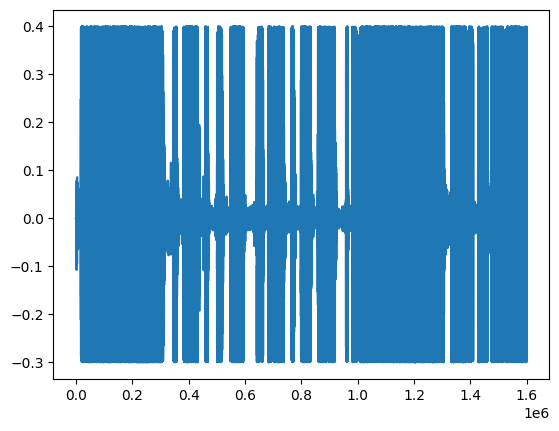

In [57]:
plt.plot(X[0,:])

## Audio Edwin Nemeguen

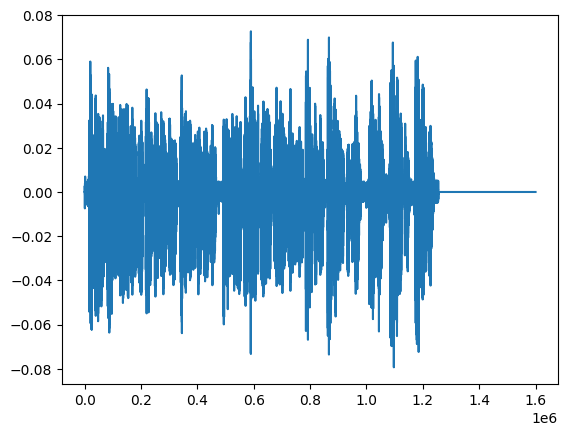

In [58]:
plt.plot(X[1,:])

## Audio Jens Stoltenberg

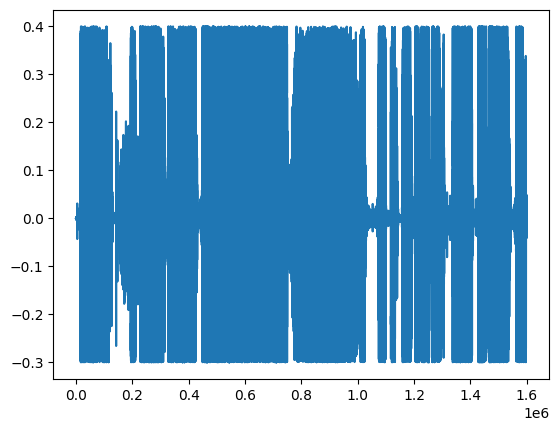

In [59]:
plt.plot(X[2,:])

## Audio Julia Gillard

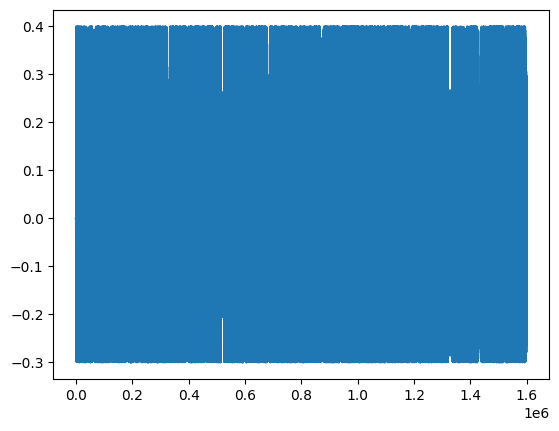

In [60]:
plt.plot(X[3,:])

## Audio Margaret Thatcher

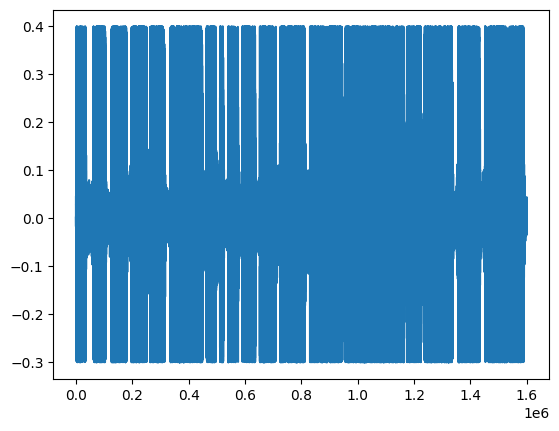

In [61]:
plt.plot(X[4,:])

## Audio Nelson Mandela

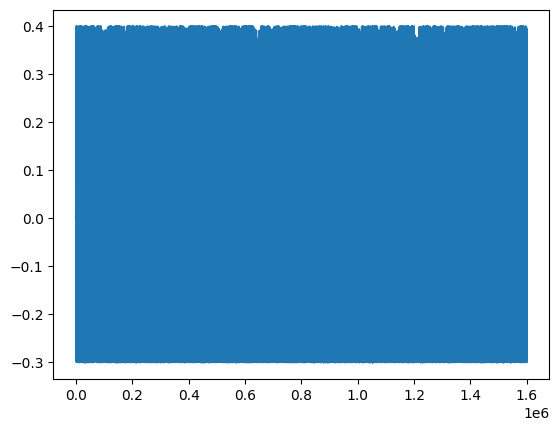

In [62]:
plt.plot(X[5,:])

## Audio background noise

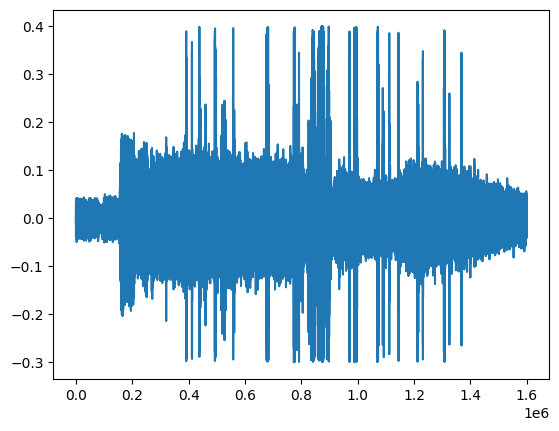

In [63]:
plt.plot(X[6,:])

In [64]:
def dividir_en_fragmentos(signal, sr, duracion_fragmento=1):

    fragmentos = []
    # Calculamos el número de muestras por fragmento
    muestras_por_fragmento = sr * duracion_fragmento

    # Dividimos la señal en fragmentos de longitud fija
    for i in range(0, len(signal), muestras_por_fragmento):
        fragmento = signal[i:i + muestras_por_fragmento]

        # Si el fragmento es más corto que el tamaño deseado, rellenarlo con ceros
        if len(fragmento) < muestras_por_fragmento:
            fragmento = np.pad(fragmento, (0, muestras_por_fragmento - len(fragmento)), 'constant')

        fragmentos.append(fragmento)

    return np.array(fragmentos)

In [65]:
def procesar_signals(signals, sr, n_hablantes):

    fragmentos = []
    etiquetas = []

    for i in range(n_hablantes):
        signal = signals[i, :]  # Obtenemos la columna i de la matriz de señales
        fragmentos_hablante = dividir_en_fragmentos(signal, sr)

        # Agregamos los fragmentos y etiquetas
        fragmentos.extend(fragmentos_hablante)
        etiquetas.extend([i] * len(fragmentos_hablante))

    # Convertimos fragmentos a numpy array
    X = np.array(fragmentos)
    y = np.array(etiquetas)

    return X, y


X_frag, y = procesar_signals(X, sr=16000, n_hablantes=7)

# Verificamos la forma final de X (los fragmentos) y y (las etiquetas)
print(f"Shape de X: {X_frag.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (700, 16000)
Shape de y: (700,)


In [66]:
def exportar_audios_por_etiqueta(X, y, sr, output_dir):

    # No aseguramos de que la carpeta de salida existe
    os.makedirs(output_dir, exist_ok=True)

    # Iteramos sobre las señales y sus etiquetas
    for idx, (audio, etiqueta) in enumerate(zip(X, y)):
        # Creamos la carpeta para la etiqueta si no existe
        etiqueta_dir = os.path.join(output_dir, str(etiqueta))
        os.makedirs(etiqueta_dir, exist_ok=True)

        # Nombre del archivo de audio
        audio_filename = os.path.join(etiqueta_dir, f"audio_{idx}.wav")

        # Guardamos el audio en formato WAV
        sf.write(audio_filename, audio, sr)

    print(f"Audios exportados en {output_dir} organizados por etiquetas.")

### Metodo por redes profundas mediante extraccion de caracteristicas de audio MFCC compacto

Esta función, `extraer_mfccs`, toma como entrada un conjunto de datos de audio, la frecuencia de muestreo y el número de coeficientes MFCC a extraer. Para cada señal de audio en los datos, calcula los coeficientes MFCC utilizando la función `librosa.feature.mfcc`. Luego, reduce estos coeficientes a una representación compacta tomando la media a lo largo del tiempo. Finalmente, almacena los coeficientes MFCC compactados en una lista y devuelve un arreglo de numpy con todos los coeficientes MFCC extraídos.

In [67]:
def extraer_mfccs(datos, sr, n_mfcc=13):

    mfccs = []
    for signal in datos:
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
        # Reduce a una representación compacta
        mfcc = np.mean(mfcc.T, axis=0)
        mfccs.append(mfcc)
    return np.array(mfccs)

In [68]:
X_mfcc_frag = extraer_mfccs(X_frag, sr)

In [69]:
X_mfcc_frag.shape

(700, 13)

In [70]:
# Normalizamos los fragmentos
scaler = MinMaxScaler()
X_normalizado = scaler.fit_transform(X_mfcc_frag)

print(X_normalizado.shape)

(700, 13)


In [71]:
print(X_normalizado)

[[0.76344223 0.42298192 0.62197615 ... 0.16219475 0.36835775 0.26662031]
 [0.91855861 0.40716674 0.64694025 ... 0.35513393 0.42450153 0.51905296]
 [0.93976696 0.37472999 0.60909367 ... 0.41011743 0.41074046 0.57054335]
 ...
 [0.74634424 0.86073393 0.70568945 ... 0.43935599 0.46468439 0.45488616]
 [0.73993539 0.83927869 0.7075052  ... 0.41639642 0.49400456 0.40005864]
 [0.73313106 0.8268833  0.74193341 ... 0.44495439 0.54914728 0.39122804]]


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X_normalizado, y, test_size=0.2, random_state=42, stratify = y)

Creación del modelo

In [73]:
# Creamos el modelo MLP
modelo = Sequential()

# Capa de entrada
modelo.add(Input(shape=(13,)))
modelo.add(Dense(512, activation='relu'))
modelo.add(Dropout(0.5))

# Capa oculta
modelo.add(Dense(256, activation='relu'))
modelo.add(Dropout(0.5))

# Capa de salida
modelo.add(Dense(7, activation='softmax'))

# Compilación del modelo
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Resumen del modelo
modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,295 (548.03 KB)

 Trainable params: 140,295 (548.03 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
callbacks = [call.ModelCheckpoint(filepath='model.best.keras', verbose = 1, save_best_only=True),\
             call.EarlyStopping(patience=5, restore_best_weights=True,min_delta=1e-3, monitor="val_loss"),\
             call.ReduceLROnPlateau(monitor='val_loss', patience = 3, verbose = 1, factor = 0.8, min_lr = 1e-5)]

modelo.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test),callbacks=callbacks,shuffle=True)

Epoch 1/30
 1/18 ━━━━━━━━━━━━━━━━━━━━ 8s 493ms/step - accuracy: 0.1875 - loss: 1.8903
Epoch 1: val_loss improved from None to 1.72591, saving model to model.best.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2268 - loss: 1.8875 - val_accuracy: 0.7500 - val_loss: 1.7259 - learning_rate: 0.0010
Epoch 2/30
 1/18 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4062 - loss: 1.7628
Epoch 2: val_loss improved from 1.72591 to 1.43903, saving model to model.best.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4321 - loss: 1.6567 - val_accuracy: 0.5214 - val_loss: 1.4390 - learning_rate: 0.0010
Epoch 3/30
 1/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5312 - loss: 1.4344
Epoch 3: val_loss improved from 1.43903 to 1.19031, saving model to model.best.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5143 - loss: 1.3890 - val_accuracy: 0.6500 - val_loss: 1.1903 - learning_rate: 0.0010
Epoch 4/30
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5534 - los

In [75]:
predicciones = modelo.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [76]:
clases_predichas = np.argmax(predicciones, axis = 1)
print(clases_predichas)

[2 6 1 6 4 0 2 4 6 4 5 1 3 5 0 4 4 4 0 0 2 3 1 3 6 4 6 2 5 4 3 3 2 5 2 4 3
 0 6 2 1 6 5 5 4 1 2 1 2 5 5 5 6 1 4 3 5 6 6 2 0 2 2 2 6 2 0 3 4 4 2 0 3 5
 6 5 0 1 2 1 3 5 4 0 1 6 3 2 6 0 3 3 6 5 6 2 1 2 1 3 1 0 1 6 0 5 5 4 4 2 1
 3 4 1 5 4 5 4 2 2 4 0 4 1 1 2 2 0 5 6 0 2 6 0 4 1 1 6 5 4]


In [77]:
accuracy = accuracy_score(y_test, clases_predichas)
print(accuracy)

0.8857142857142857


In [78]:
y_test

array([0, 6, 1, 6, 3, 0, 2, 3, 6, 3, 5, 1, 3, 5, 0, 4, 4, 4, 2, 0, 0, 3,
       1, 3, 6, 3, 6, 0, 5, 4, 3, 3, 2, 5, 4, 4, 3, 0, 6, 2, 1, 6, 5, 5,
       4, 1, 2, 1, 2, 5, 5, 5, 6, 1, 4, 3, 5, 6, 6, 2, 0, 2, 2, 2, 6, 3,
       2, 3, 4, 4, 2, 0, 3, 5, 6, 5, 0, 1, 2, 1, 3, 5, 4, 0, 1, 6, 2, 2,
       6, 0, 3, 3, 6, 5, 6, 2, 1, 0, 1, 3, 1, 3, 1, 6, 0, 5, 5, 4, 4, 2,
       1, 3, 4, 1, 5, 4, 5, 4, 2, 2, 4, 0, 4, 1, 1, 0, 0, 0, 5, 6, 0, 2,
       6, 0, 4, 1, 1, 6, 5, 4])

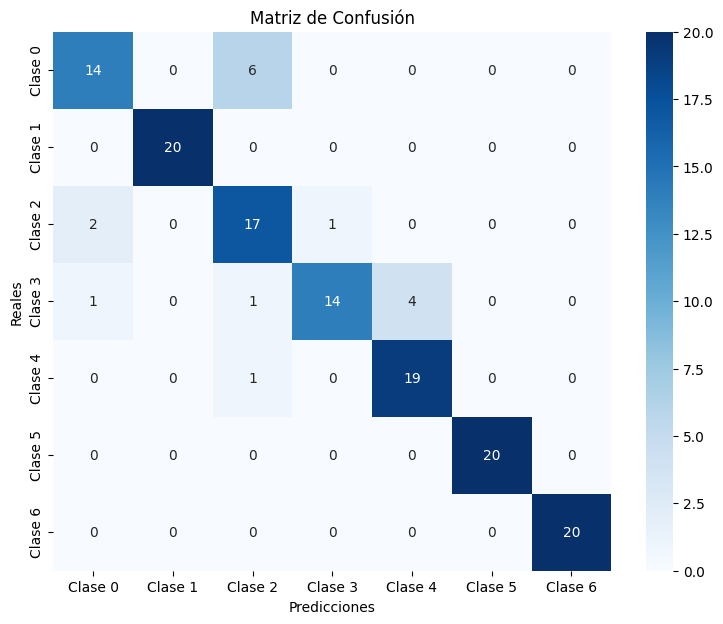

In [79]:
# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, clases_predichas)

# Visualizamos la matriz de confusión
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=["Clase 0", "Clase 1", "Clase 2", "Clase 3", "Clase 4", "Clase 5", "Clase 6"], 
    yticklabels=["Clase 0", "Clase 1", "Clase 2", "Clase 3", "Clase 4", "Clase 5", "Clase 6"])
plt.xlabel("Predicciones")
plt.ylabel("Reales")
plt.title("Matriz de Confusión")
plt.show()

### Metodo por redes neuronales convolucionales 2D

modelo con convolucionales se usó espectrograma mel y no mfcc

Un espectrograma Mel es una representación visual de la energía de las frecuencias de una señal de audio a lo largo del tiempo, utilizando una escala de frecuencia Mel, que se asemeja a la percepción humana del sonido. Se crea dividiendo la señal de audio en ventanas, aplicando la Transformada de Fourier a cada ventana para obtener el espectro de frecuencias, mapeando las frecuencias a la escala Mel y visualizando la energía de estas frecuencias a lo largo del tiempo. Es útil en aplicaciones de procesamiento de audio y reconocimiento de voz.

In [80]:
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

In [81]:
S = librosa.feature.melspectrogram(y=X_frag, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)
x_conv = np.expand_dims(S_dB, axis=-1)

In [82]:
dataset_normalizado = (x_conv - x_conv.min()) / (x_conv.max() - x_conv.min())

In [83]:
# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(dataset_normalizado, y, test_size=0.2, random_state=42, stratify=y)

# Mostramos las formas de los conjuntos de datos
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")


Forma de X_train: (560, 128, 32, 1)
Forma de X_test: (140, 128, 32, 1)
Forma de y_train: (560,)
Forma de y_test: (140,)


# MODELO CNN

Este código define y entrena una red neuronal convolucional (CNN) para clasificar audio. Utiliza Keras para construir el modelo con capas de convolución, max-pooling y dropout. El modelo se compila con el optimizador Adam y se entrena con datos de audio preprocesados. Se configuran callbacks para guardar el mejor modelo, detener el entrenamiento temprano y ajustar la tasa de aprendizaje. Finalmente, el modelo se evalúa en el conjunto de prueba y se imprime la precisión obtenida.

**IMPORTANTE**: modelo con convolucionales se usó espectrograma mel y no mfcc

In [84]:
# Definición del modelo
tf.keras.utils.set_random_seed(42)
modelo = Sequential()
modelo.add(Input(shape=(x_conv.shape[1], x_conv.shape[2], 1)))
modelo.add(Conv2D(16, 3, activation="relu", padding="same"))
modelo.add(MaxPooling2D(pool_size=2, strides=2, padding='same'))
modelo.add(Dropout(0.5))
modelo.add(Conv2D(16, 3, activation="relu", padding="same"))
modelo.add(MaxPooling2D(pool_size=2, strides=2, padding='same'))
modelo.add(Dropout(0.5))
modelo.add(Flatten())
modelo.add(Dense(len(set(y)), activation='softmax'))
modelo.summary()

# Visualizamos el modelo
plot_model(modelo, to_file='model_plot.png', show_shapes=True, show_layer_names=True, rankdir='LR')

# Compilamos el modelo
modelo.compile(optimizer=Adam(learning_rate=0.005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [call.ModelCheckpoint(filepath='model.best.keras', verbose = 1, save_best_only=True),\
             call.EarlyStopping(patience=5, restore_best_weights=True,min_delta=1e-3, monitor="val_loss"),\
             call.ReduceLROnPlateau(monitor='val_loss', patience = 3, verbose = 1, factor = 0.8, min_lr = 1e-5)]

historia = modelo.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test),callbacks=callbacks,shuffle=True)

# Evaluamos el modelo
loss, accuracy = modelo.evaluate(X_test, y_test)
print(f'Precisión del modelo: {accuracy * 100:.2f}%')


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 32, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 8, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 8, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │        28,679 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,159 (121.71 KB)

 Trainable params: 31,159 (121.71 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1792 - loss: 2.0278
Epoch 1: val_loss improved from None to 1.62395, saving model to model.best.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2357 - loss: 1.9194 - val_accuracy: 0.3143 - val_loss: 1.6240 - learning_rate: 0.0050
Epoch 2/50
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3566 - loss: 1.4878
Epoch 2: val_loss improved from 1.62395 to 1.35253, saving model to model.best.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4089 - loss: 1.4420 - val_accuracy: 0.4214 - val_loss: 1.3525 - learning_rate: 0.0050
Epoch 3/50
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4784 - loss: 1.2541
Epoch 3: val_loss improved from 1.35253 to 1.06274, saving model to model.best.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5304 - loss: 1.1860 - val_accuracy: 0.6357 - val_

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


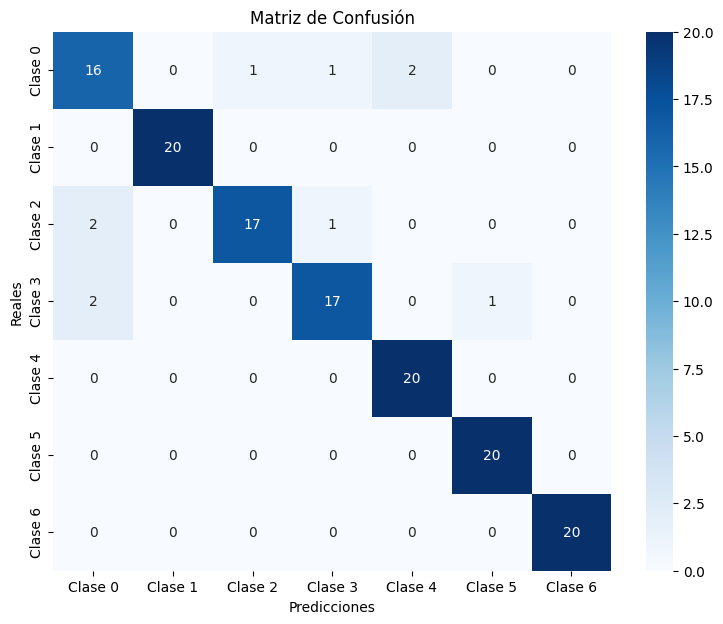

In [85]:
# Realizamos predicciones en el conjunto de prueba
predicciones = modelo.predict(X_test)
clases_predichas = np.argmax(predicciones, axis=1)

# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, clases_predichas)

# Visualizamos la matriz de confusión
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Clase 0", "Clase 1", "Clase 2", "Clase 3", "Clase 4", "Clase 5", "Clase 6"], 
    yticklabels=["Clase 0", "Clase 1", "Clase 2", "Clase 3", "Clase 4", "Clase 5", "Clase 6"])
plt.xlabel("Predicciones")
plt.ylabel("Reales")
plt.title("Matriz de Confusión")
plt.show()


# Metodo por redes recurrentes

El código a continuación implementa un enfoque de clasificación de audio utilizando redes neuronales recurrentes (RNN). A diferencia de los métodos anteriores que usaron características compactas (MFCC promediado) o espectrogramas 2D, este método trata el audio como secuencias temporales.

**Características principales del método:**

**Extracción de características secuenciales**: Se extraen coeficientes MFCC por cada fragmento de audio, manteniendo la dimensión temporal para crear secuencias de características a lo largo del tiempo.

**Padding y normalización**: Las secuencias se ajustan a una longitud máxima usando padding con ceros, y se normalizan por coeficiente MFCC para mejorar la convergencia del modelo.

In [86]:
def extraer_mfcc_por_fragmento(signals, sr=16000, n_mfcc=13, hop_length=512):
    secuencias = []
    max_len = 0
    # Primero calculamos MFCC de cada fragmento
    for sig in signals:
        mf = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
        mf = mf.T  # (time_steps, n_mfcc)
        secuencias.append(mf)
        if mf.shape[0] > max_len:
            max_len = mf.shape[0]
    # Padding
    X = np.zeros((len(secuencias), max_len, n_mfcc), dtype=np.float32)
    for i, mf in enumerate(secuencias):
        X[i, :mf.shape[0], :] = mf
    return X

In [87]:
X_mfcc = extraer_mfcc_por_fragmento(X_frag, sr=16000, n_mfcc=13)

# Normalización por coeficiente (eje 0 y 1 agregados)
mean = X_mfcc.mean(axis=(0,1), keepdims=True)
std  = X_mfcc.std(axis=(0,1), keepdims=True) + 1e-8
X_mfcc_norm = (X_mfcc - mean) / std

In [88]:
from sklearn.model_selection import train_test_split
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(
    X_mfcc_norm, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

**Arquitectura RNN bidireccional**: El modelo utiliza capas LSTM bidireccionales que pueden procesar la información en ambas direcciones temporales, capturando mejor las dependencias temporales en el audio.

**Manejo de secuencias variables**: Se utiliza una capa de Masking para ignorar los valores de padding durante el entrenamiento, permitiendo trabajar con secuencias de diferentes longitudes de manera eficiente.

In [89]:
timesteps = X_train_rnn.shape[1]
n_feats = X_train_rnn.shape[2]
n_classes = len(np.unique(y))

inp = Input(shape=(timesteps, n_feats))
x = Masking(mask_value=0.0)(inp)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Bidirectional(LSTM(64))(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(n_classes, activation='softmax')(x)

modelo_rnn = Model(inp, out)
modelo_rnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

modelo_rnn.summary()

es = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
rlr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.5, min_lr=1e-5)

hist = modelo_rnn.fit(
    X_train_rnn, y_train_rnn,
    validation_data=(X_test_rnn, y_test_rnn),
    epochs=80,
    batch_size=32,
    callbacks=[es, rlr],
    shuffle=True
)

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 32, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 32, 13)    │          0 │ input_layer_5[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 32, 13)    │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 32)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 32, 128)   │     39,936 │ masking_1[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │     98,816 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ bidirectional_3[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 7)         │        455 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 147,463 (576.03 KB)

 Trainable params: 147,463 (576.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.5018 - loss: 1.6030 - val_accuracy: 0.7357 - val_loss: 1.1695 - learning_rate: 0.0010
Epoch 2/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7679 - loss: 0.8983 - val_accuracy: 0.8500 - val_loss: 0.6003 - learning_rate: 0.0010
Epoch 3/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8750 - loss: 0.4550 - val_accuracy: 0.8857 - val_loss: 0.3539 - learning_rate: 0.0010
Epoch 4/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9250 - loss: 0.2892 - val_accuracy: 0.9286 - val_loss: 0.2298 - learning_rate: 0.0010
Epoch 5/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9429 - loss: 0.2156 - val_accuracy: 0.9571 - val_loss: 0.1811 - learning_rate: 0.0010
Epoch 6/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9714 - loss: 0.1212 - val_accuracy: 0.9143 - val_loss: 0.2119 - learning_rate: 0.0010
Epoch 7/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9696 - loss: 0.1179 - val_acc

Este enfoque es especialmente útil para capturar patrones temporales complejos en las características del habla, como la entonación, ritmo y variaciones temporales que son características distintivas de cada hablante.

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        20
           1       1.00      1.00      1.00        20
           2       0.85      0.85      0.85        20
           3       0.95      0.95      0.95        20
           4       0.95      0.90      0.92        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20

    accuracy                           0.94       140
   macro avg       0.94      0.94      0.94       140
weighted avg       0.94      0.94      0.94       140



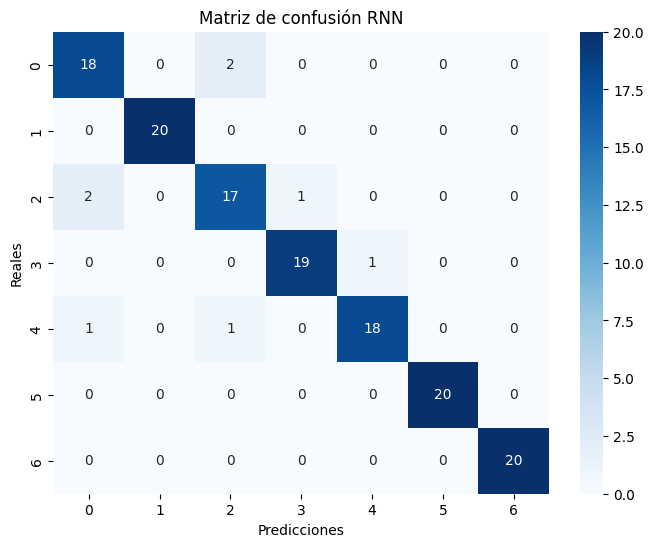

In [90]:
pred = np.argmax(modelo_rnn.predict(X_test_rnn), axis=1)
print(classification_report(y_test_rnn, pred))

cm = confusion_matrix(y_test_rnn, pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicciones')
plt.ylabel('Reales')
plt.title('Matriz de confusión RNN')
plt.show()